In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
from scipy.sparse import dia
#load dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target


In [ ]:
#Train_Test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('Training shape:',X_train.shape,)
print('Testing shape:',X_test.shape,)


Training shape: (353, 10)
Testing shape: (89, 10)


In [ ]:
class LinearRegressionScratch:
  def __init__(self,learning_rate=0.01,n_iters=5000):
    self.lr=learning_rate
    self.n_iters=n_iters
    self.weights=None
    self.bias=None
  def fit(self,X,y):
    n_samples,n_features=X.shape
    self.weights=np.zeros(n_features)
    self.bias=0
    for _ in range(self.n_iters):
      y_pred=np.dot(X,self.weights)+self.bias
      dw=(1/n_samples)*np.dot(X.T,(y_pred-y))
      db=(1/n_samples)*np.sum(y_pred-y)
      self.weights-=self.lr*dw
      self.bias-=self.lr*db

  def predict(self,X):
    y_pred=np.dot(X,self.weights)+self.bias
    return y_pred


In [ ]:
# Train Model
model = LinearRegressionScratch(learning_rate=0.01,n_iters=5000)
model.fit(X_train,y_train)


In [ ]:
#Make Predictions
y_pred=model.predict(X_test)

In [19]:
# Evaluate Model
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print('Mean Squared Error:',mse)
print('R2 Score:',r2)


Mean Squared Error: 4077.008441134034
R2 Score: 0.23048477381276744


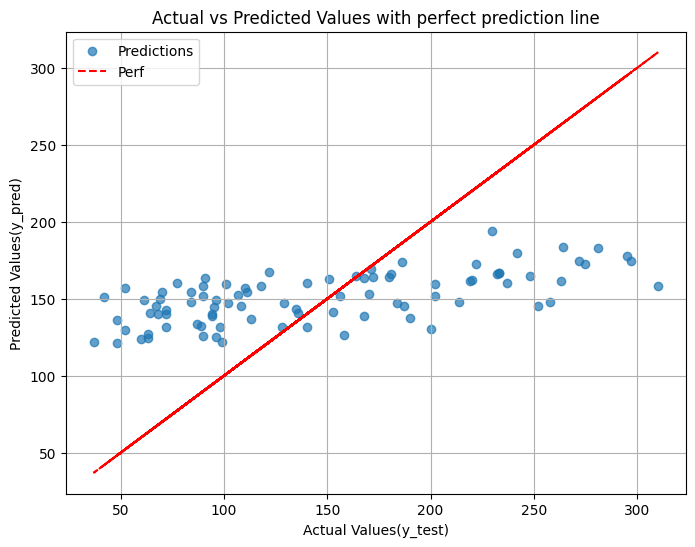

In [22]:
#Visulaziation
from matplotlib.lines import lineStyles
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.7,label='Predictions')
plt.plot(y_test,y_test,color='red',linestyle='--',label='Perf')
plt.xlabel('Actual Values(y_test)')
plt.ylabel('Predicted Values(y_pred)')
plt.title('Actual vs Predicted Values with perfect prediction line')
plt.legend()
plt.grid(True)
plt.show()